2025-05-07 15:30:50.983463: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

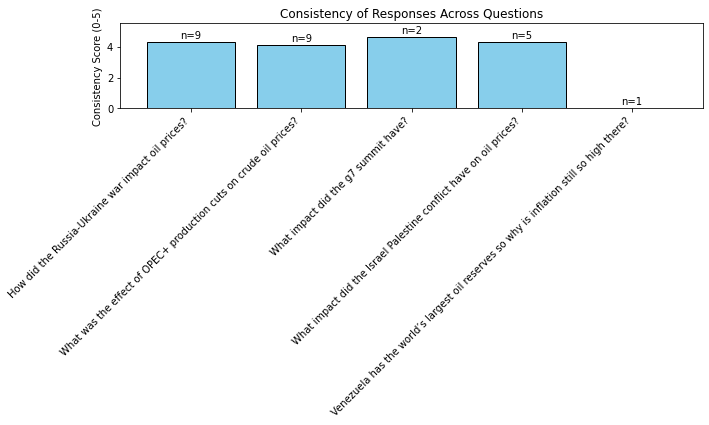

Question: How did the Russia-Ukraine war impact oil prices?
Number of valid responses: 9
Consistency Score: 4.27/5
--------------------------------------------------
Question: What was the effect of OPEC+ production cuts on crude oil prices?
Number of valid responses: 9
Consistency Score: 4.12/5
--------------------------------------------------
Question: What impact did the g7 summit have?
Number of valid responses: 2
Consistency Score: 4.59/5
--------------------------------------------------
Question: What impact did the Israel Palestine conflict have on oil prices?
Number of valid responses: 5
Consistency Score: 4.32/5
--------------------------------------------------
Question: Venezuela has the world’s largest oil reserves so why is inflation still so high there?
Number of valid responses: 1
Consistency Score: 0.0/5
--------------------------------------------------
Plotting heatmap for question with most responses: How did the Russia-Ukraine war impact oil prices?


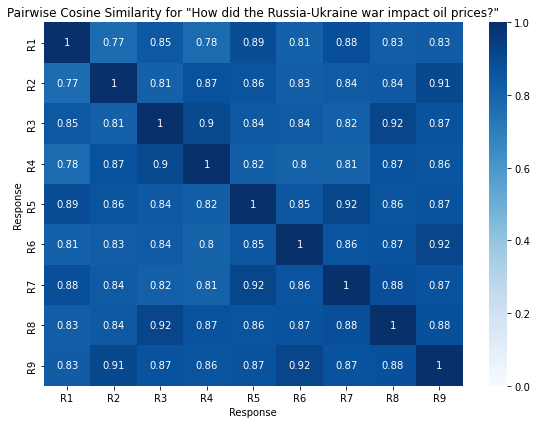

In [ ]:
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

def parse_responses(file_path):

    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # split the content by question
    questions = content.split('--------------------CONSISTENCY CHECK')
    question_responses = {}
    
    for question_block in questions[1:]
        # extract question text
        question_match = re.search(r"'(.*?)'", question_block)
        if not question_match:
            continue
        question = question_match.group(1)
        
        runs = question_block.split('Run ')
        summaries = []
        
        for run in runs[1:]:

            if 'EVALUATED AS INVALID' in run:
                continue
            
            # llm summary
            summary_match = re.search(r"LLM SUMMARY:-\n''''''''''\n(.*?)''''''''''", run, re.DOTALL)
            if summary_match:
                summary = summary_match.group(1).strip()
                summaries.append(summary)
        
        if summaries:  # only if valid responses
            question_responses[question] = summaries
    
    return question_responses

def compute_consistency(summaries):
    """
    Compute the consistency score for a list of summaries using cosine similarity.
    Returns a score between 0 and 5 and the similarity matrix.
    """
    if len(summaries) < 2:
        return 0.0, None
    
    # embeddings
    embeddings = model.encode(summaries)
    sim_matrix = cosine_similarity(embeddings)
    
    triu_indices = np.triu_indices_from(sim_matrix, k=1)
    pairwise_similarities = sim_matrix[triu_indices]
    
    if len(pairwise_similarities) == 0:
        return 0.0, None
    
    avg_similarity = np.mean(pairwise_similarities)
    
    # 0-5 scale
    consistency_score = avg_similarity * 5
    
    return round(consistency_score, 2), sim_matrix

def plot_similarity_heatmap(summaries, question, sim_matrix):
    
    if sim_matrix is None or len(summaries) < 2:
        print(f"Cannot plot heatmap for '{question}': Insufficient valid responses.")
        return
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(sim_matrix, annot=True, cmap='Blues', vmin=0, vmax=1, 
                xticklabels=[f'R{i+1}' for i in range(len(summaries))], 
                yticklabels=[f'R{i+1}' for i in range(len(summaries))])
    plt.title(f'Pairwise Cosine Similarity for "{question}"')
    plt.xlabel('Response')
    plt.ylabel('Response')
    plt.tight_layout()
    
    plt.savefig(f'similarity_heatmap_{question[:30]}.png')
    plt.show()

def main(file_path):

    question_responses = parse_responses(file_path)
    
    max_responses = 0
    selected_question = None
    selected_summaries = None
    selected_sim_matrix = None
    
    for question, summaries in question_responses.items():
        score, sim_matrix = compute_consistency(summaries)
        num_responses = len(summaries)
        if num_responses > max_responses:
            max_responses = num_responses
            selected_question = question
            selected_summaries = summaries
            selected_sim_matrix = sim_matrix
        
        print(f"Question: {question}")
        print(f"Number of valid responses: {num_responses}")
        print(f"Consistency Score: {score}/5")
        print("-" * 50)
    
    if selected_question:
        print(f"Plotting heatmap for question with most responses: {selected_question}")
        plot_similarity_heatmap(selected_summaries, selected_question, selected_sim_matrix)

if __name__ == "__main__":
    file_path = "responses_consistency.txt"
    main(file_path)